# Lab Report: Binary Classification with PyTorch

## Abstract
This report details the process of building and evaluating a binary classification model using PyTorch. The objective is to classify data points into one of two categories based on two input features. We will cover data loading, preprocessing, model definition, training, and visualization of the decision boundary.

## 1. Introduction
This section outlines the problem statement and the tools used for solving it.

In [209]:
import pandas as pd
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

## 2. Data Preparation
This section covers the steps taken to load and preprocess the dataset for training and testing the model.

In [210]:
path='binary_classification_moons.csv'

In [211]:
data=pd.read_csv(path)
data.head(6)

,X1,X2,label
0,-0.009332,0.390981,1
1,0.954574,-0.473756,1
2,0.918526,-0.425196,1
3,0.412768,-0.376385,1
4,-0.845320,0.528799,0
5,0.579542,-0.352979,1


In [212]:
X = data[['X1', 'X2']].values #combining data
Y = data['label'].values

In [213]:
## Turn data into tensors
X=torch.tensor(X)
Y=torch.tensor(Y)

In [214]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=0.2,
                                                    random_state=42)



### 2.1 Data Splitting
The dataset is split into training and testing sets to evaluate the model's generalization performance.

In [215]:
#making device agnostic code:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [216]:
# Build model with non-linear activation function
from torch import nn
class ModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
        self.relu = nn.ReLU() # <- add in ReLU activation function
        # Can also put sigmoid in the model
        # This would mean you don't need to use it on the predictions
        # self.sigmoid = nn.Sigmoid()

    def forward(self, x):
      # Intersperse the ReLU activation function between layers
       return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_2 = ModelV2().to(device)
print(model_2)

ModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)


add image download.png here

In [217]:
# 1. Setup settings
model = model_2
epochs = 800
train_loss_history = []
test_loss_history = []

# 2. Define Loss and Optimizer
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.1)

In [218]:
# Convert your data to the correct PyTorch data types
X_train = X_train.float()
X_test = X_test.float()
y_train = y_train.float()  # Use .float() for BCEWithLogitsLoss
y_test = y_test.float()

# 3. The Core Training and Testing Loop
for epoch in range(epochs):
    ### Training Mode
    model.train()
    y_logits = model(X_train).squeeze() # Get raw network outputs
    loss = loss_fn(y_logits, y_train)   # Calculate training loss

    optimizer.zero_grad()               # Clear old gradients
    loss.backward()                     # Backpropagation
    optimizer.step()                    # Update model weights
    train_loss_history.append(loss.item())
    test_loss_history.append(test_loss.item())

    ### Testing Mode
    model.eval()
    with torch.inference_mode():
        test_logits = model(X_test).squeeze()
        test_loss = loss_fn(test_logits, y_test)

    # Print progress every 10 epochs
    if epoch % 10 == 0 or epoch == epochs - 1:
        print(f"Epoch: {epoch} | Train Loss: {loss:.5f} | Test Loss: {test_loss:.5f}")

Epoch: 0 | Train Loss: 0.66810 | Test Loss: 0.66638
Epoch: 10 | Train Loss: 0.62401 | Test Loss: 0.62508
Epoch: 20 | Train Loss: 0.57265 | Test Loss: 0.57742
Epoch: 30 | Train Loss: 0.51593 | Test Loss: 0.52460
Epoch: 40 | Train Loss: 0.45851 | Test Loss: 0.46979
Epoch: 50 | Train Loss: 0.40851 | Test Loss: 0.42173
Epoch: 60 | Train Loss: 0.36787 | Test Loss: 0.38197
Epoch: 70 | Train Loss: 0.33659 | Test Loss: 0.35034
Epoch: 80 | Train Loss: 0.31264 | Test Loss: 0.32532
Epoch: 90 | Train Loss: 0.29428 | Test Loss: 0.30548
Epoch: 100 | Train Loss: 0.28008 | Test Loss: 0.28967
Epoch: 110 | Train Loss: 0.26893 | Test Loss: 0.27691
Epoch: 120 | Train Loss: 0.26008 | Test Loss: 0.26658
Epoch: 130 | Train Loss: 0.25302 | Test Loss: 0.25824
Epoch: 140 | Train Loss: 0.24733 | Test Loss: 0.25150
Epoch: 150 | Train Loss: 0.24275 | Test Loss: 0.24604
Epoch: 160 | Train Loss: 0.23899 | Test Loss: 0.24155
Epoch: 170 | Train Loss: 0.23586 | Test Loss: 0.23781
Epoch: 180 | Train Loss: 0.23321 | Test

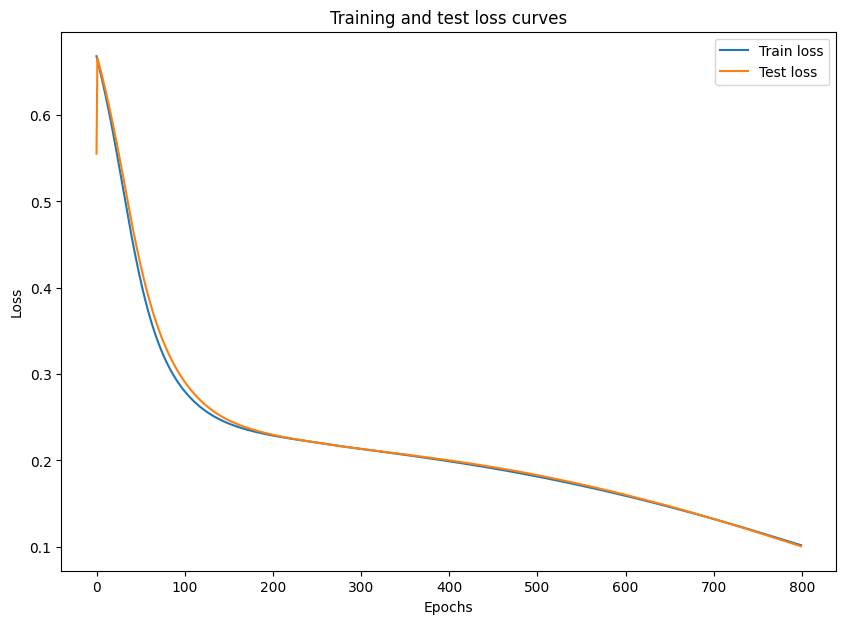

In [219]:
import matplotlib.pyplot as plt

# Since these are now standard Python lists of numbers over time,
# len() will work perfectly to map out your epochs!
epoch_count = list(range(len(train_loss_history)))

plt.figure(figsize=(10, 7))
plt.plot(epoch_count, train_loss_history, label="Train loss")
plt.plot(epoch_count, test_loss_history, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()
plt.show()

In [220]:
# 4. Helper function to plot decision boundaries (Built right here!)
def local_plot_boundary(model, X, y):
    # Create a grid of points covering the data area
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

    # Predict the class for every point on the grid
    grid_points = torch.from_numpy(np.c_[xx.ravel(), yy.ravel()]).float()
    model.eval()
    with torch.inference_mode():
        preds = torch.sigmoid(model(grid_points)).round().numpy()

    # Plot the boundary colors and the actual data points
    plt.contourf(xx, yy, preds.reshape(xx.shape), alpha=0.7, cmap=plt.cm.RdYlBu)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu, edgecolors="k")

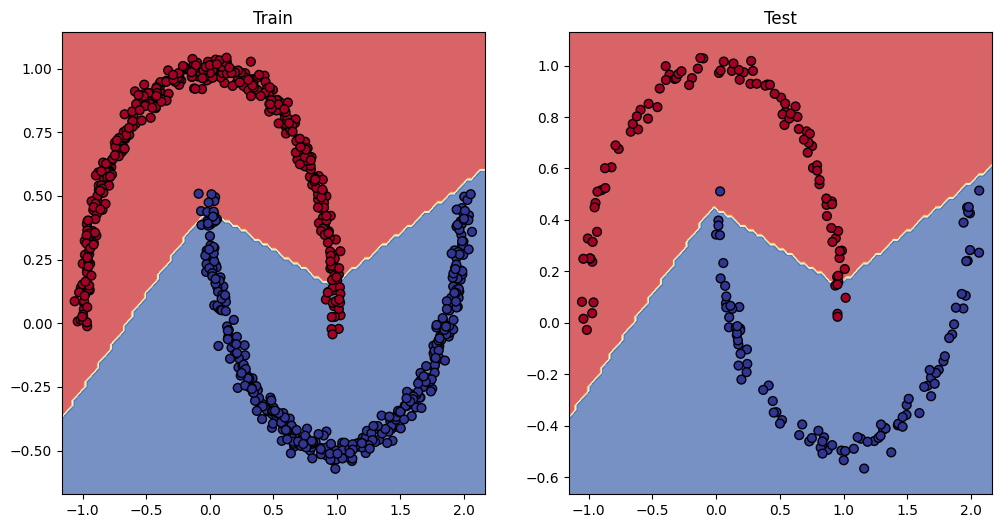

In [221]:
# 5. Plot the Results
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Train")
local_plot_boundary(model, X_train, y_train)

plt.subplot(1, 2, 2)
plt.title("Test")
local_plot_boundary(model, X_test, y_test)

plt.show()

Model is underfitting so we need to add more layers or neurons

In [222]:
import torch.nn as nn

class ModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        # Increasing out_features gives the model more "neurons" to think with
        self.layer_1 = nn.Linear(in_features=2, out_features=16) # Boosted to 16
        self.layer_2 = nn.Linear(in_features=16, out_features=16) # Boosted to 16
        self.layer_3 = nn.Linear(in_features=16, out_features=1)
        self.relu = nn.ReLU()

    def forward(self, x):
        # Pass data through layers and activate with ReLU to allow curves
        x = self.relu(self.layer_1(x))
        x = self.relu(self.layer_2(x))
        x = self.layer_3(x) # Output raw logits directly
        return x

# Instantiate the new model
model_3 = ModelV2()



In [223]:
# 1. Setup settings
model = model_3
epochs = 800
train_loss_history = []
test_loss_history = []

# 2. Define Loss and Optimizer
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.1)

In [224]:
# Convert your data to the correct PyTorch data types
X_train = X_train.float()
X_test = X_test.float()
y_train = y_train.float()  # Use .float() for BCEWithLogitsLoss
y_test = y_test.float()

# 3. The Core Training and Testing Loop
for epoch in range(epochs):
    ### Training Mode
    model.train()
    y_logits = model(X_train).squeeze() # Get raw network outputs
    loss = loss_fn(y_logits, y_train)   # Calculate training loss

    optimizer.zero_grad()               # Clear old gradients
    loss.backward()                     # Backpropagation
    optimizer.step()                    # Update model weights
    train_loss_history.append(loss.item())
    test_loss_history.append(test_loss.item())

    ### Testing Mode
    model.eval()
    with torch.inference_mode():
        test_logits = model(X_test).squeeze()
        test_loss = loss_fn(test_logits, y_test)

    # Print progress every 10 epochs
    if epoch % 10 == 0 or epoch == epochs - 1:
        print(f"Epoch: {epoch} | Train Loss: {loss:.5f} | Test Loss: {test_loss:.5f}")

Epoch: 0 | Train Loss: 0.67771 | Test Loss: 0.67559
Epoch: 10 | Train Loss: 0.64714 | Test Loss: 0.64708
Epoch: 20 | Train Loss: 0.60848 | Test Loss: 0.61017
Epoch: 30 | Train Loss: 0.55575 | Test Loss: 0.56058
Epoch: 40 | Train Loss: 0.49340 | Test Loss: 0.50280
Epoch: 50 | Train Loss: 0.43411 | Test Loss: 0.44743
Epoch: 60 | Train Loss: 0.38614 | Test Loss: 0.40162
Epoch: 70 | Train Loss: 0.35074 | Test Loss: 0.36628
Epoch: 80 | Train Loss: 0.32472 | Test Loss: 0.33898
Epoch: 90 | Train Loss: 0.30477 | Test Loss: 0.31738
Epoch: 100 | Train Loss: 0.28881 | Test Loss: 0.29976
Epoch: 110 | Train Loss: 0.27603 | Test Loss: 0.28534
Epoch: 120 | Train Loss: 0.26590 | Test Loss: 0.27357
Epoch: 130 | Train Loss: 0.25760 | Test Loss: 0.26387
Epoch: 140 | Train Loss: 0.25069 | Test Loss: 0.25581
Epoch: 150 | Train Loss: 0.24483 | Test Loss: 0.24900
Epoch: 160 | Train Loss: 0.23979 | Test Loss: 0.24319
Epoch: 170 | Train Loss: 0.23532 | Test Loss: 0.23818
Epoch: 180 | Train Loss: 0.23127 | Test

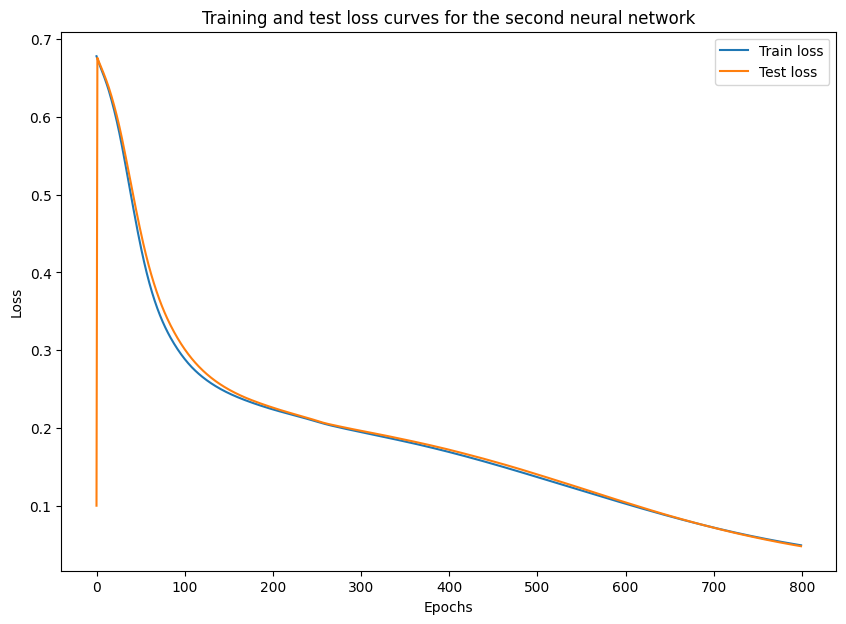

In [225]:
import matplotlib.pyplot as plt

# Since these are now standard Python lists of numbers over time,
# len() will work perfectly to map out your epochs!
epoch_count = list(range(len(train_loss_history)))

plt.figure(figsize=(10, 7))
plt.plot(epoch_count, train_loss_history, label="Train loss")
plt.plot(epoch_count, test_loss_history, label="Test loss")
plt.title("Training and test loss curves for the second neural network")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()
plt.show()

In [226]:
# 4. Helper function to plot decision boundaries (Built right here!)
def local_plot_boundary(model, X, y):
    # Create a grid of points covering the data area
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

    # Predict the class for every point on the grid
    grid_points = torch.from_numpy(np.c_[xx.ravel(), yy.ravel()]).float()
    model.eval()
    with torch.inference_mode():
        preds = torch.sigmoid(model(grid_points)).round().numpy()

    # Plot the boundary colors and the actual data points
    plt.contourf(xx, yy, preds.reshape(xx.shape), alpha=0.7, cmap=plt.cm.RdYlBu)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu, edgecolors="k")

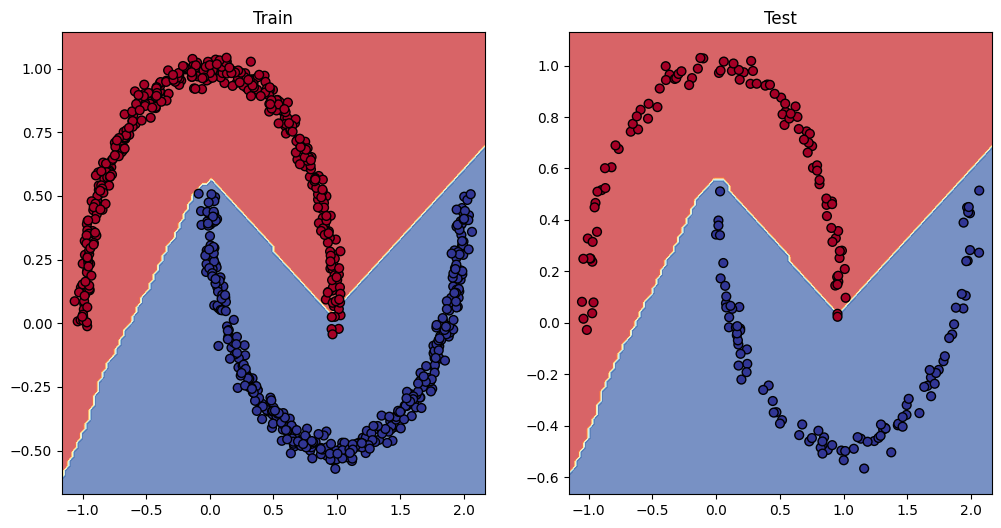

In [227]:
# 5. Plot the Results
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Train")
local_plot_boundary(model, X_train, y_train)

plt.subplot(1, 2, 2)
plt.title("Test")
local_plot_boundary(model, X_test, y_test)

plt.show()